In [4]:
kagglehub.login()

In [6]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('playground-series-s6e8', output_dir='data')

print("Path to competition files:", path)

100%|██████████████████████████████████████| 19.7M/19.7M [00:01<00:00, 15.2MB/s]

Extracting files...


Path to competition files: data


In [1]:
import numpy as np
import pandas as pd 
import os
from sklearn.preprocessing import LabelEncoder

df = pd.read_csv('data/train.csv')
df_test = pd.read_csv('data/test.csv')

# Step 1 - EDA

In [2]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

Data type for each feature looks correct.

In [4]:
(df.isnull().sum()/(len(df)))*100

id                          0.000000
age                         4.184307
daily_screen_time_hours    13.864376
social_media_hours         19.381112
gaming_hours               18.343461
work_study_hours            7.451592
sleep_hours                 6.433612
notifications_per_day       9.775388
app_opens_per_day          11.673940
weekend_screen_time        16.208855
gender                      4.199494
stress_level                7.976638
academic_work_impact        6.396584
addicted_label              0.000000
dtype: float64

In [5]:
(df_test.isnull().sum()/(len(df)))*100

id                         0.000000
age                        2.478850
daily_screen_time_hours    4.742475
social_media_hours         6.855529
gaming_hours               8.594542
work_study_hours           4.017681
sleep_hours                3.247904
notifications_per_day      4.949745
app_opens_per_day          3.717986
weekend_screen_time        7.332843
gender                     2.055632
stress_level               2.838716
academic_work_impact       3.720300
dtype: float64

There are null values for both test and train. This means we cannot drop nulls

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,691369.0,345684.000000,199581.183467,0.00,172842.00,345684.00,518526.00,691368.00
age,662440.0,26.615408,5.153162,18.00,22.00,27.00,31.00,35.00
daily_screen_time_hours,595515.0,7.640865,2.721446,0.50,5.48,7.77,9.84,15.00
social_media_hours,557374.0,2.471038,1.316137,0.00,1.45,2.31,3.37,8.00
gaming_hours,564548.0,1.459265,0.934552,0.00,0.70,1.33,2.09,4.00
work_study_hours,639851.0,2.366971,1.258797,0.00,1.36,2.20,3.20,6.00
sleep_hours,646889.0,6.804334,1.234512,4.50,5.78,6.80,7.87,9.00
notifications_per_day,623785.0,145.894900,65.917556,20.00,93.00,150.00,204.00,250.00
app_opens_per_day,610659.0,102.636781,48.093970,15.00,64.00,104.00,145.00,180.00
weekend_screen_time,579306.0,9.479866,2.856006,0.51,7.28,9.58,11.75,17.56


Ranges of values look appropirate. We don't see any outliers at a first glance.

Overall, this dataset is high-quality and does not require any fixing.

# Step 2 - EDA graph plot

In [7]:
cat_cols=df.select_dtypes(include=['object']).columns
num_cols = df.select_dtypes(include=['int64','float64']).columns
print("Categorical Variables:")
print(cat_cols)
print("Numerical Variables:")
print(num_cols)

Categorical Variables:
Index(['gender', 'stress_level', 'academic_work_impact'], dtype='object')
Numerical Variables:
Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'addicted_label'],
      dtype='object')


id
Skew : 0.0


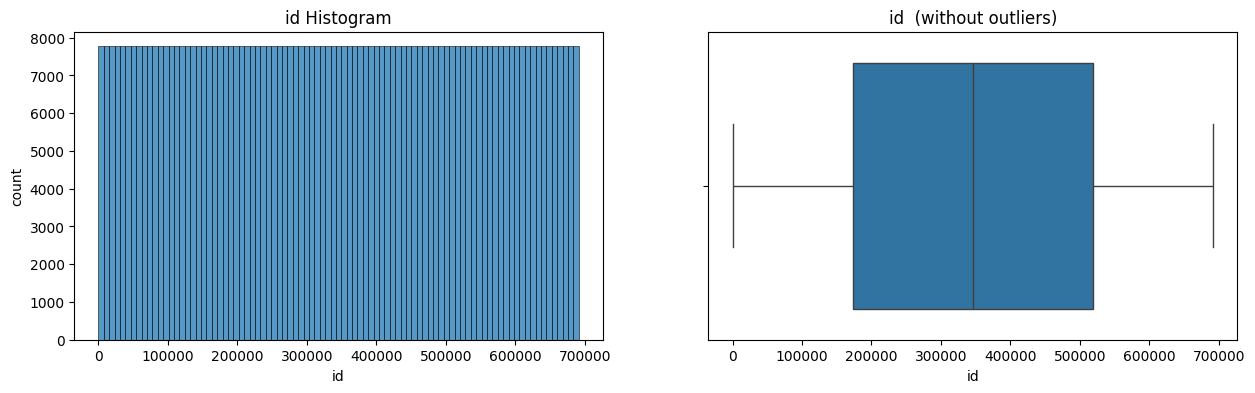

age
Skew : -0.04


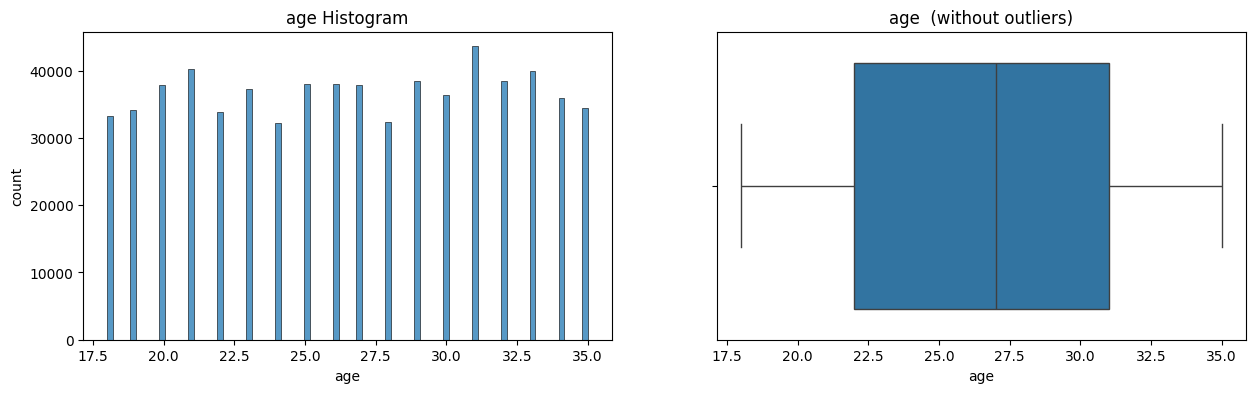

daily_screen_time_hours
Skew : -0.13


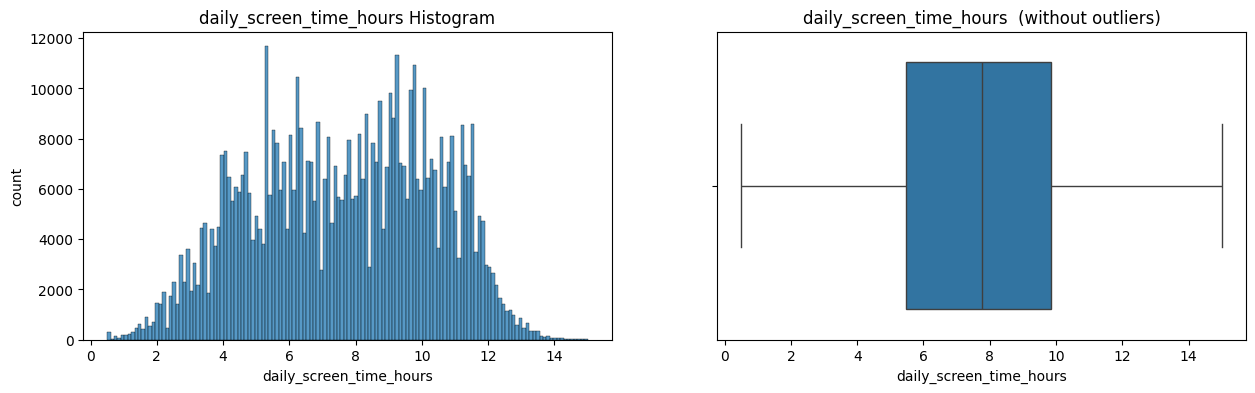

social_media_hours
Skew : 0.47


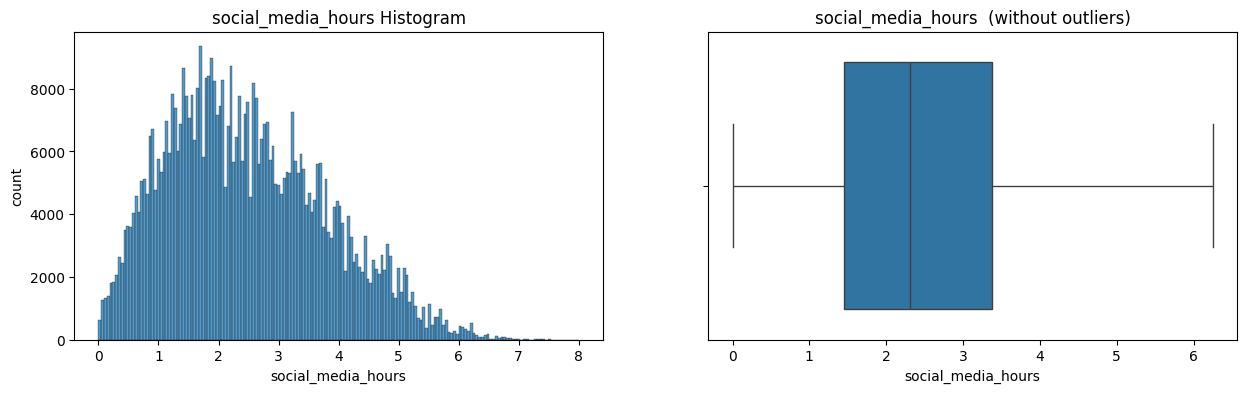

gaming_hours
Skew : 0.54


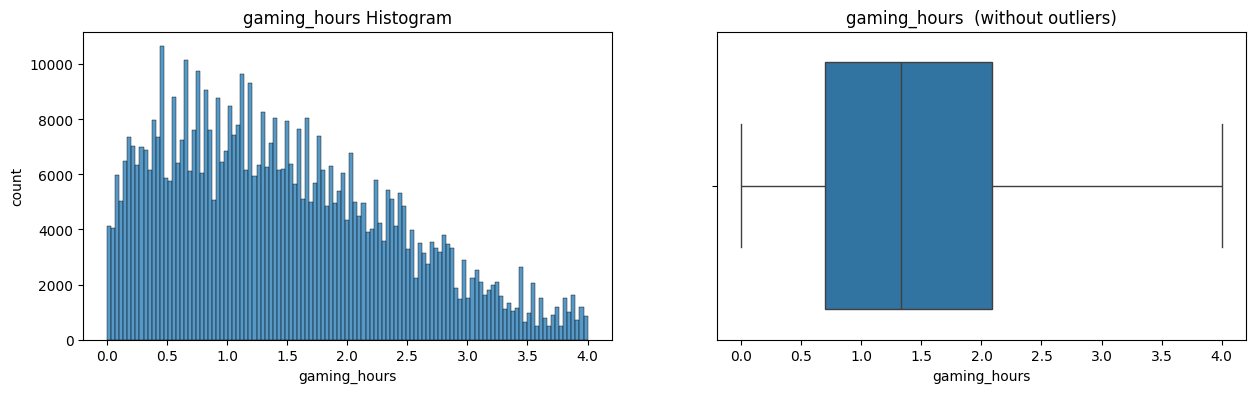

work_study_hours
Skew : 0.56


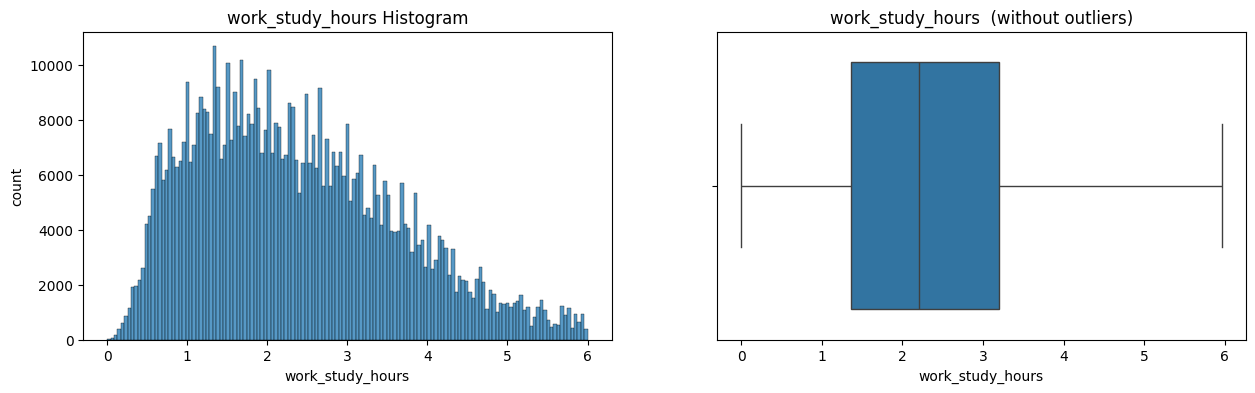

sleep_hours
Skew : -0.01


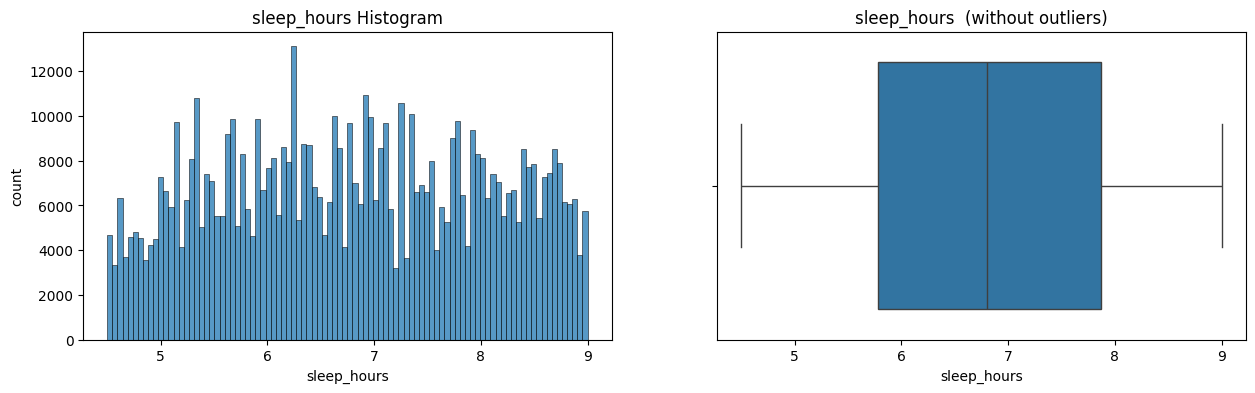

notifications_per_day
Skew : -0.21


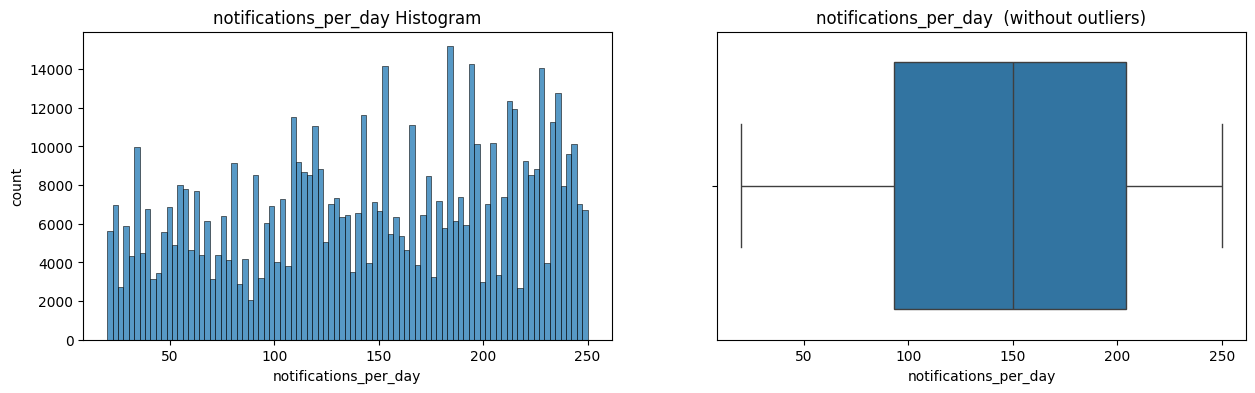

app_opens_per_day
Skew : -0.13


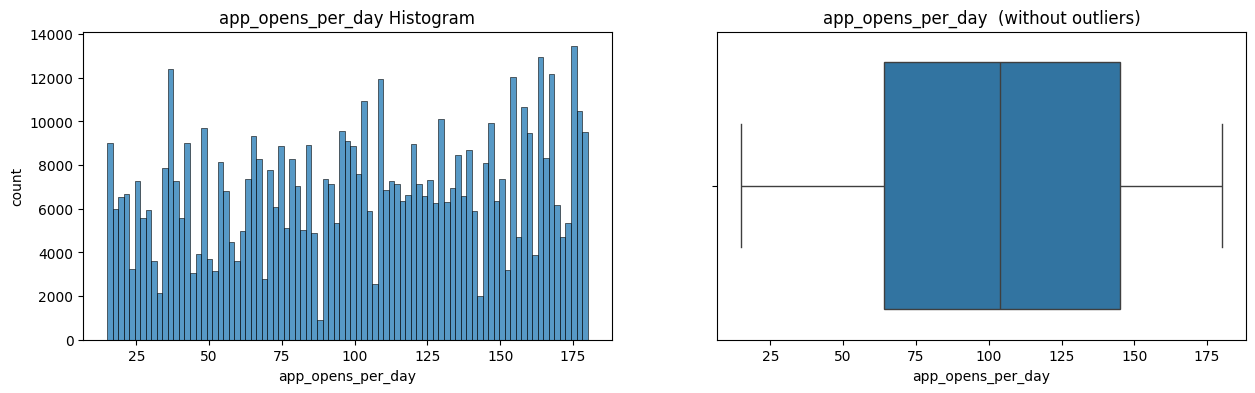

weekend_screen_time
Skew : -0.06


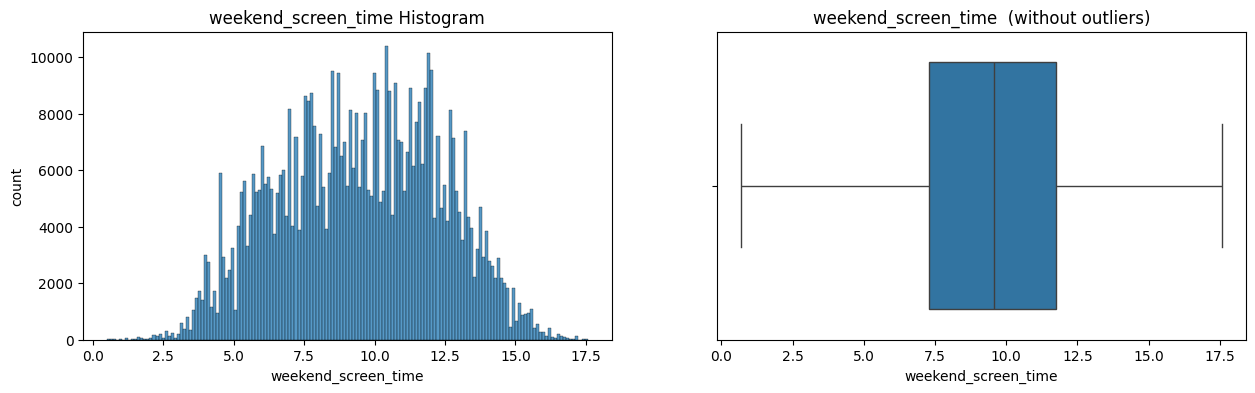

addicted_label
Skew : -0.92


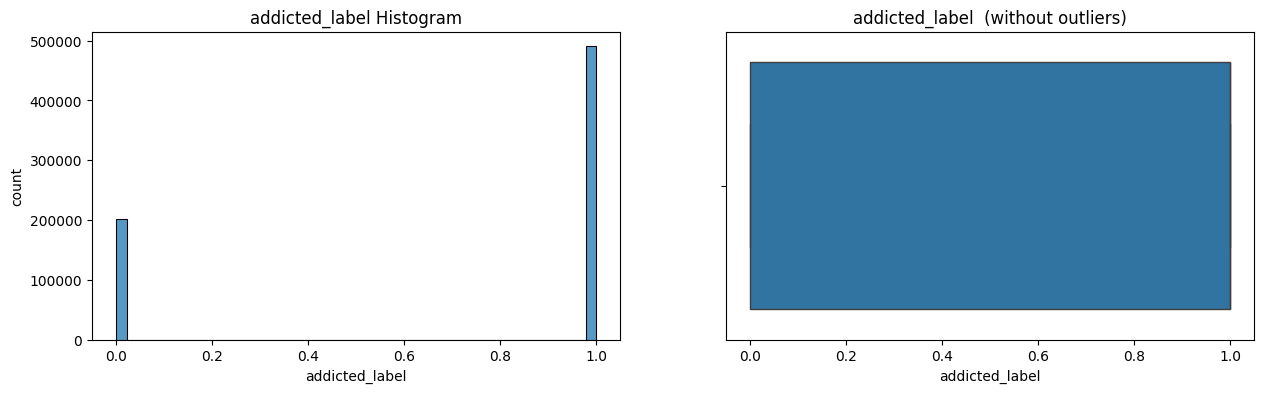

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    print(col)
    print('Skew :', round(df[col].skew(), 2))
    plt.figure(figsize=(15, 4))
    
    # Histogram without outliers
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col)
    plt.ylabel('count')
    plt.title(f'{col} Histogram')
    
    # Boxplot without outliers
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col], showfliers=False)
    plt.title(f'{col}  (without outliers)')
    
    plt.show()

In [9]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,10.78,3.25,1.57,1.65,7.71,86.0,94.0,12.89,Male,NaN,No,1
691365,691365,20.0,3.45,1.86,0.89,0.30,6.59,221.0,42.0,8.47,Female,High,No,1
691366,691366,NaN,NaN,NaN,NaN,2.06,6.16,NaN,86.0,7.79,Other,Medium,No,1
691367,691367,22.0,11.78,3.69,0.23,1.35,5.53,171.0,62.0,7.71,Other,NaN,NaN,1


In [10]:
target_cols = ["gender", "stress_level", "academic_work_impact"]
df[target_cols] = df[target_cols].fillna("Missing")

df_test[target_cols] = df_test[target_cols].fillna("Missing")
encoder = LabelEncoder()
for i in target_cols:
    df[i] = encoder.fit_transform(df[i])
    df_test[i] = encoder.fit_transform(df_test[i])

In [11]:
hours_cols = ['daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours', 'sleep_hours','notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
df[hours_cols] = df[hours_cols]/24
df_test[hours_cols] = df_test[hours_cols]/24

In [12]:
df

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,0.076250,0.066250,0.087917,0.310833,5.083333,1.583333,0.359583,1,2,1,1
1,1,19.0,0.248750,0.045000,NaN,0.126250,0.342500,3.166667,0.791667,NaN,0,2,1,0
2,2,18.0,0.212083,NaN,NaN,NaN,0.260417,5.583333,2.500000,0.311250,0,1,2,0
3,3,21.0,0.267500,0.052500,0.059167,0.140000,0.368750,4.666667,3.916667,0.360833,3,1,0,1
4,4,26.0,0.466667,0.077917,0.117083,0.081250,0.218750,NaN,NaN,0.557917,0,2,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,22.0,0.449167,0.135417,0.065417,0.068750,0.321250,3.583333,3.916667,0.537083,1,3,1,1
691365,691365,20.0,0.143750,0.077500,0.037083,0.012500,0.274583,9.208333,1.750000,0.352917,0,0,1,1
691366,691366,NaN,NaN,NaN,NaN,0.085833,0.256667,NaN,3.583333,0.324583,3,2,1,1
691367,691367,22.0,0.490833,0.153750,0.009583,0.056250,0.230417,7.125000,2.583333,0.321250,3,3,0,1


Each category also has the same amount of data. Dataset is very balanced.

# Step 4 - Bivariate Analysis

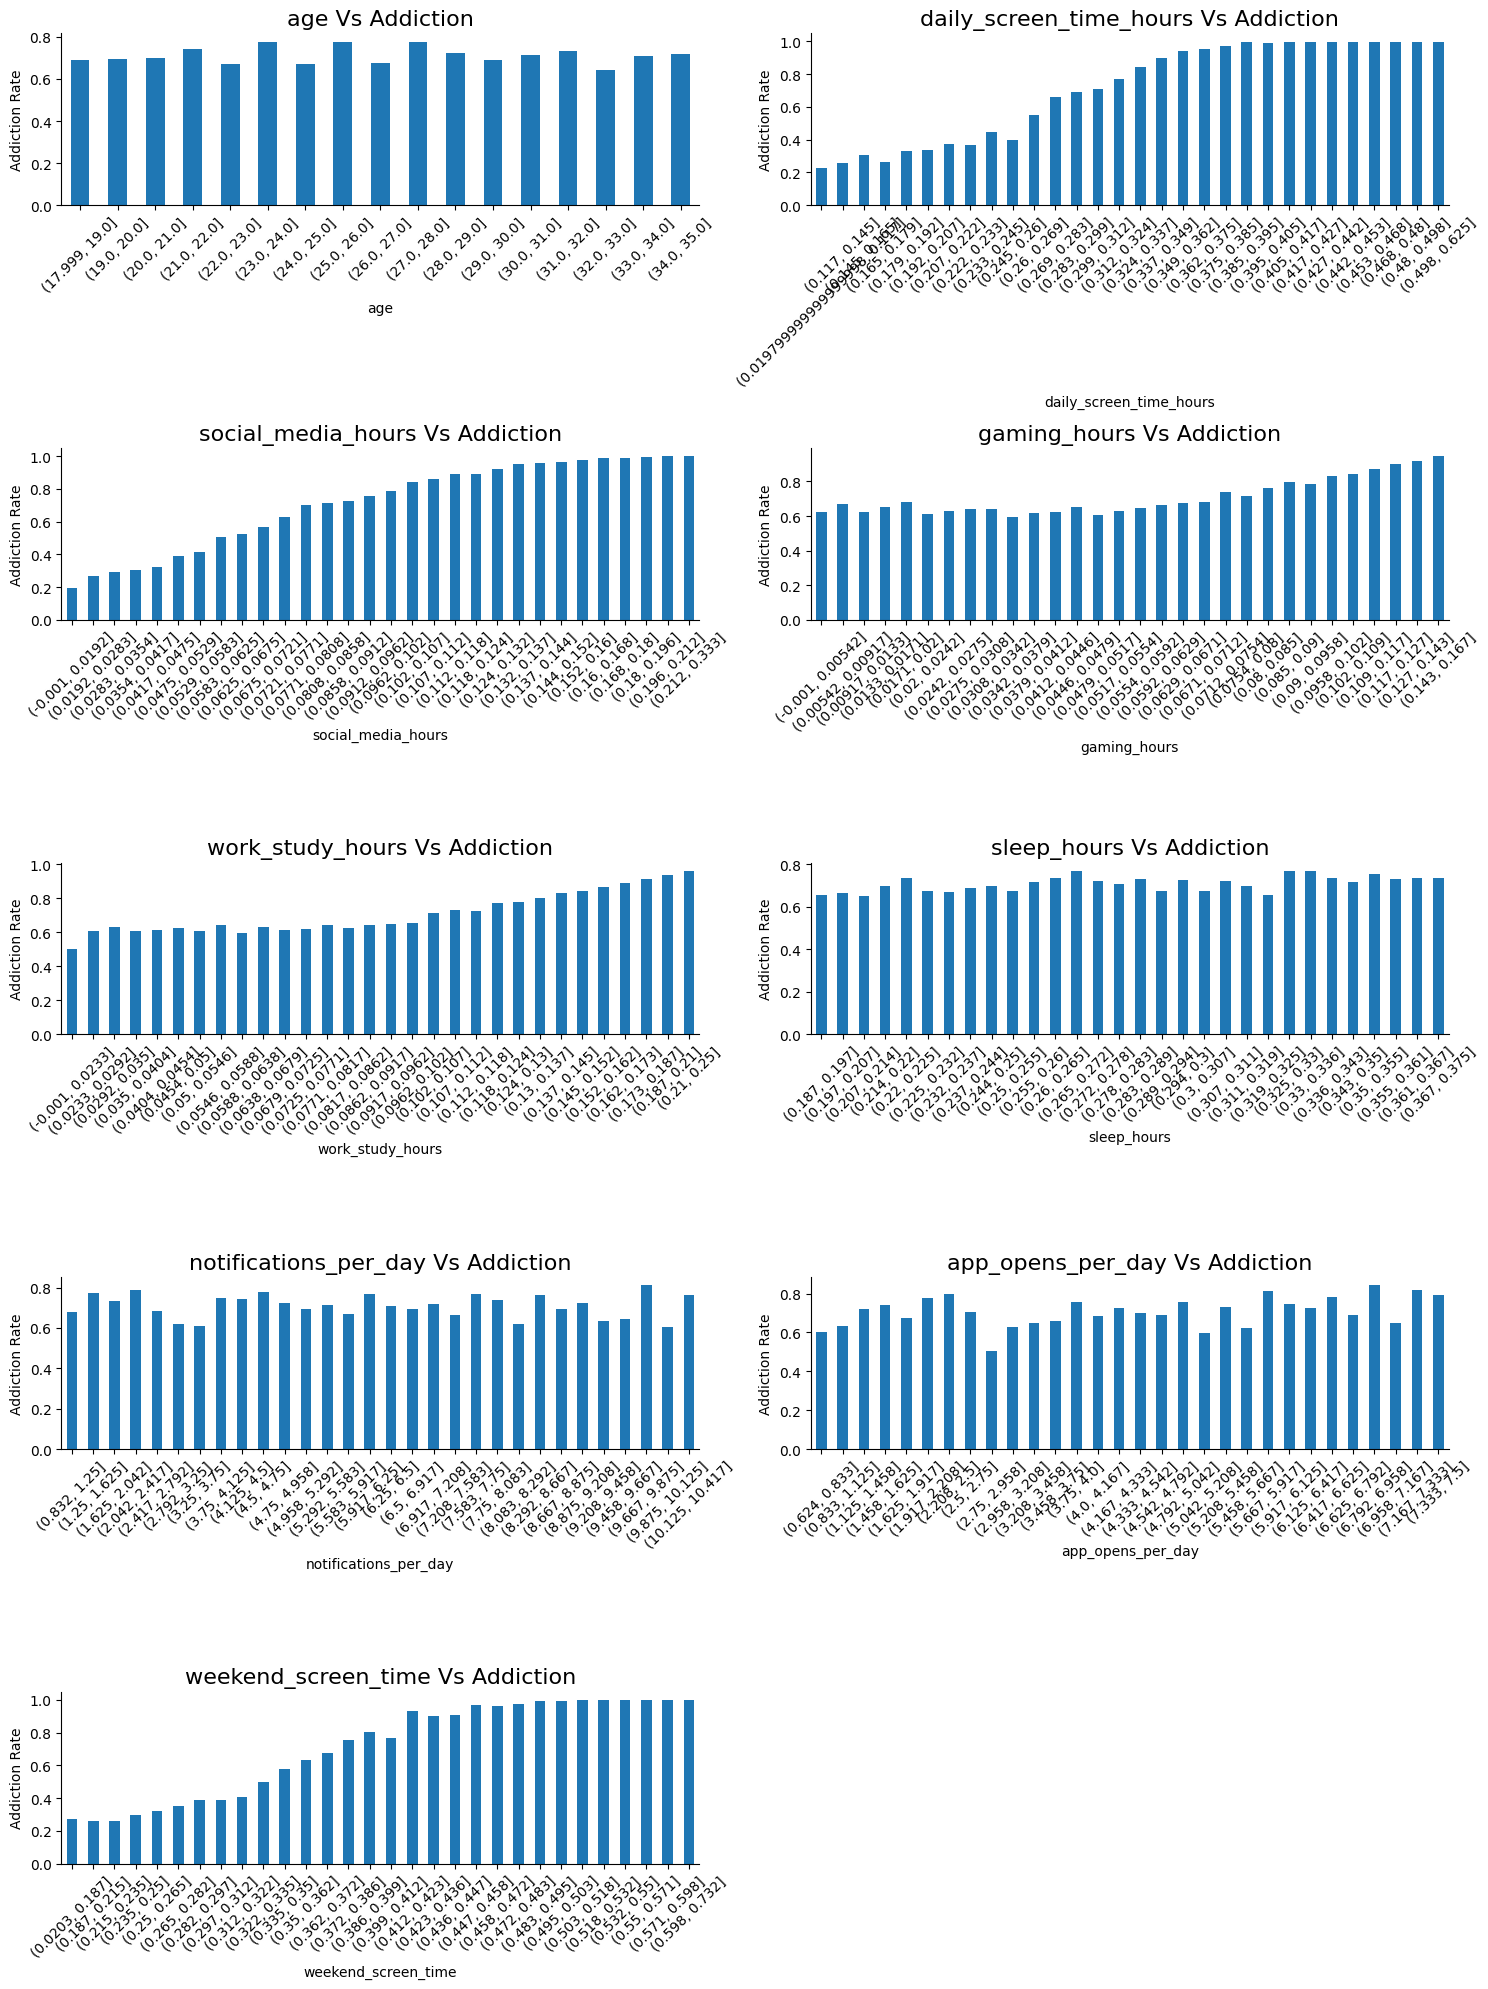

In [13]:
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_plot = num_cols.drop(['id','addicted_label'])

ncols = 2
nrows = math.ceil(len(cols_to_plot) / ncols)

fig, axarr = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axarr = axarr.flatten()

for i, col in enumerate(cols_to_plot):

    # Create bins for continuous variables
    binned = pd.qcut(df[col], q=30, duplicates='drop')

    addiction_rate = (
        df.groupby(binned, observed=True)['addicted_label']
        .mean()
    )

    addiction_rate.plot.bar(
        ax=axarr[i],
        fontsize=10
    )

    axarr[i].set_title(f"{col} Vs Addiction", fontsize=16)
    axarr[i].set_xlabel(col)
    axarr[i].set_ylabel("Addiction Rate")
    axarr[i].tick_params(axis='x', rotation=45)

# Hide unused axes
for i in range(len(cols_to_plot), len(axarr)):
    axarr[i].set_visible(False)

plt.tight_layout()
sns.despine()
plt.show()

A lot of interesting variations are shown. Categories affect salary. 

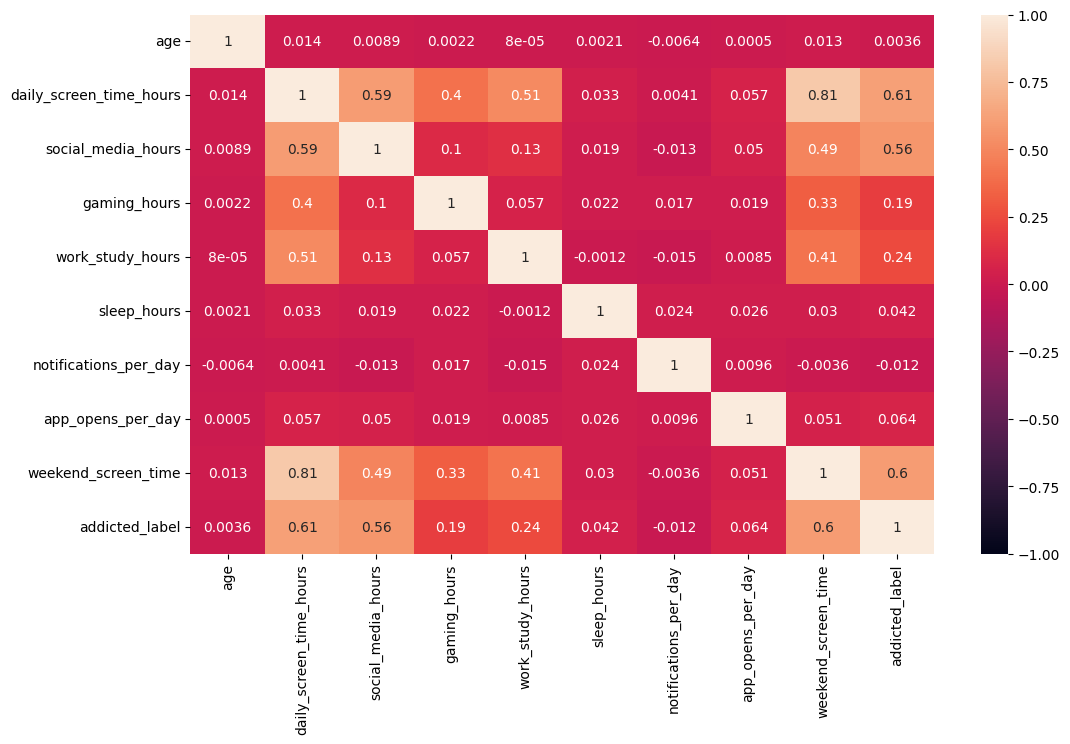

In [14]:
plt.figure(figsize=(12, 7))

sns.heatmap(df[num_cols.drop('id')].corr(method='spearman'), annot = True, vmin = -1, vmax = 1)
plt.show()

Positive correlation between salary and both experience and the number of skills

In [15]:
df.columns

Index(['id', 'age', 'daily_screen_time_hours', 'social_media_hours',
       'gaming_hours', 'work_study_hours', 'sleep_hours',
       'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
       'gender', 'stress_level', 'academic_work_impact', 'addicted_label'],
      dtype='object')

In [16]:
X_train, y_train = df.drop(['addicted_label','id', 'sleep_hours','app_opens_per_day', 'notifications_per_day','age'], axis=1), df[['addicted_label']]
X_test = df_test.drop(['id', 'sleep_hours','app_opens_per_day', 'notifications_per_day','age'], axis=1)

In [17]:
from sklearn.model_selection import  StratifiedKFold, cross_val_score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Step 6 - Hyperparameter tuning & Train ML

Will be using Bayesian optimization to find the best hyper parameter values. 

In [18]:
import optuna
from xgboost import XGBClassifier

def objective(trial):
    params = {
        'n_estimators'       : trial.suggest_int('n_estimators', 200, 1000),
        'max_depth'          : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'      : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'          : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'   : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'   : trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha'          : trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda'         : trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'gamma'              : trial.suggest_float('gamma', 0.0, 1.0),
        'eval_metric'        : 'auc',
        'enable_categorical' : True,
        'verbosity'          : 0
    }

    model = XGBClassifier(**params,device="cuda")
    scores = cross_val_score(
        model, X_train, y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )    
    return scores.mean()  

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-08-19 17:57:57,919] A new study created in memory with name: no-name-e36cc8b5-f05f-4ff5-9bc0-376c4851b727


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-19 17:58:08,379] Trial 0 finished with value: 0.9334023993709568 and parameters: {'n_estimators': 305, 'max_depth': 5, 'learning_rate': 0.010263397204755153, 'subsample': 0.9975880066571605, 'colsample_bytree': 0.8593695990171804, 'min_child_weight': 1, 'reg_alpha': 0.022443092750531246, 'reg_lambda': 0.0003763414326463094, 'gamma': 0.6665967291594757}. Best is trial 0 with value: 0.9334023993709568.
[I 2026-08-19 17:58:15,676] Trial 1 finished with value: 0.9308868349084681 and parameters: {'n_estimators': 283, 'max_depth': 3, 'learning_rate': 0.022424964387844953, 'subsample': 0.8361150417863014, 'colsample_bytree': 0.8466022279147887, 'min_child_weight': 3, 'reg_alpha': 0.3071310286626854, 'reg_lambda': 4.237394345036464, 'gamma': 0.0726189205604082}. Best is trial 0 with value: 0.9334023993709568.
[I 2026-08-19 17:58:49,306] Trial 2 finished with value: 0.9612279488386741 and parameters: {'n_estimators': 768, 'max_depth': 8, 'learning_rate': 0.026223212366047022, 'subsam

In [19]:
xgb = XGBClassifier(**study.best_params, device="cuda")
xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.6512770404586306
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegr

In [20]:
predicted_values_xgb = xgb.predict_proba(X_test)[:, 1]
predicted_values_xgb.tolist()

/home/dev/anaconda3/envs/ai/lib/python3.14/site-packages/xgboost/core.py:751: UserWarning: [18:05:16] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


[0.999678373336792,
 0.9576570987701416,
 0.9650580883026123,
 0.9886250495910645,
 0.9973264932632446,
 0.8721752762794495,
 0.8331849575042725,
 0.3189423382282257,
 0.9927736520767212,
 0.3023146092891693,
 0.9999673366546631,
 0.7820018529891968,
 0.9987881779670715,
 0.9264882206916809,
 0.9614952802658081,
 0.9999996423721313,
 0.027901694178581238,
 0.992496132850647,
 0.9999840259552002,
 0.9999983310699463,
 0.7235511541366577,
 0.9978415966033936,
 0.5267561674118042,
 0.9997614026069641,
 0.9377054572105408,
 0.004263622220605612,
 0.9987743496894836,
 0.9996707439422607,
 0.9997312426567078,
 0.13491277396678925,
 0.9999817609786987,
 0.9226336479187012,
 0.9999915361404419,
 0.26110562682151794,
 0.8281688094139099,
 0.44892239570617676,
 0.9998258948326111,
 0.9997449517250061,
 0.11630840599536896,
 0.927639901638031,
 0.17225059866905212,
 0.9991629123687744,
 0.4832332730293274,
 0.999996542930603,
 0.22323626279830933,
 0.9240747094154358,
 0.132576122879982,
 0.12491

In [21]:
import pandas as pd

result = pd.DataFrame(
    {'id': df_test['id'].to_list(),
     'addicted_label': predicted_values_xgb.tolist()
    })

In [22]:
result

,id,addicted_label
0,691369,0.999678
1,691370,0.957657
2,691371,0.965058
3,691372,0.988625
4,691373,0.997326
...,...,...
296297,987666,0.999999
296298,987667,0.911761
296299,987668,0.209993
296300,987669,0.817604


In [23]:
result.to_csv('result.csv', index=False)

Let's compare the performance of LR against XGBRegressor

In [24]:
from catboost import CatBoostClassifier

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1000),
        'depth': trial.suggest_int('depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'random_strength': trial.suggest_float('random_strength', 0, 1.0),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 3, 10.0),
        'loss_function': 'Logloss',
        'verbose': False
    }

    model = CatBoostClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20, show_progress_bar=True)

[I 2026-08-19 18:05:30,472] A new study created in memory with name: no-name-ea0204cc-fa77-4086-9e87-684ba2911fea


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-08-19 18:06:58,469] Trial 0 finished with value: 0.9606235542286988 and parameters: {'iterations': 634, 'depth': 10, 'learning_rate': 0.2831850198496404, 'random_strength': 0.8567285104092364, 'l2_leaf_reg': 4.270450069698641}. Best is trial 0 with value: 0.9606235542286988.
[I 2026-08-19 18:07:55,051] Trial 1 finished with value: 0.9605291347287022 and parameters: {'iterations': 441, 'depth': 10, 'learning_rate': 0.09271727394286378, 'random_strength': 0.04221364936710725, 'l2_leaf_reg': 8.423589275018646}. Best is trial 0 with value: 0.9606235542286988.
[W 2026-08-19 18:08:52,704] Trial 2 failed with parameters: {'iterations': 868, 'depth': 8, 'learning_rate': 0.07540940794937827, 'random_strength': 0.9815689092277191, 'l2_leaf_reg': 6.793536080027122} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/home/dev/anaconda3/envs/ai/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = 

KeyboardInterrupt: 

In [46]:
params = {
        'iterations': 200,
        'depth': 3,
        'learning_rate':  0.01,
        'subsample': 0.5,
        'colsample_bylevel': 0.5,
        'min_data_in_leaf': 3,
        'l2_leaf_reg': 1e-5,
        'random_strength': 10.0,
        'bagging_temperature': 2.0, 
        'eval_metric': 'AUC',
        'loss_function': 'Logloss',
        'verbose': False,
        'task_type': 'GPU'
    }

model = CatBoostClassifier(**params)

model.fit(X_train, y_train)

CatBoostError: catboost/private/libs/options/catboost_options.cpp:795: Error: default bootstrap type (bayesian) doesn't support 'subsample' option